In [164]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import shelve
import string
import numba as nb
import timeit
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib import colors
from scipy.stats import cauchy
from scipy.signal import savgol_filter
from tqdm import tqdm

In [630]:
@nb.njit()
def calc_angle(anglenew,angleold, angle_ind):
    
    if anglenew-angleold>1.9*np.pi:
        angle_ind-=2*np.pi
    elif anglenew-angleold<-1.9*np.pi:
        angle_ind+=2*np.pi
    return angle_ind

In [631]:
@nb.njit()
def NMSE(yeval,ydata):
    
    nmse = 0
    
    for j in nb.prange(yeval.shape[0]):
        nmse += (ydata[j]-yeval[j])**2
    nmse=nmse/numba_norm(ydata[:])**2
    return nmse

@nb.njit() 
def numba_norm(a):
    n = a.shape[0]
    norm = 0
    for i in range(n):
        norm += a[i] * a[i]
    return np.sqrt(norm)

def udata(h,v1=0.1,M=100_000):
    Udata = v1*np.arange(0,M)*h/2
    return Udata


In [632]:

@nb.njit()
def flimit(z,p,w,u):
    K,F = p[0], p[1]
    dz = (F/2)*(np.exp(1j*u)-np.exp(-1j*u)*z**2)+(1j*w-1)*z-(K/4)*((np.conjugate(z)+z)*z**2-z-np.conjugate(z))
    return dz

@nb.njit()
def frk4_step(z,u0,umid,u1,p,h,w):

    kz1 = flimit(z,p,w,u0)

    kz2 = flimit(z + 0.5*h*kz1,p,w,umid)

    kz3 = flimit(z + 0.5*h*kz2 ,p,w,umid)

    kz4= flimit(z + h*kz3,p,w,u1)

    yz =z + h*(1.0 / 6.0)*(kz1 + 2 * kz2 + 2 * kz3 + kz4)

    return yz
@nb.njit()
def solver(z0,U1,U2,U3,p,h,w,steps =1000):
    angle_ind =0
    Yz = np.empty(steps, dtype = 'complex128')
    YPsi = np.empty(steps, dtype = 'float64')
    for i in nb.prange(steps):
        yz = frk4_step(z0,U1[i],U2[i],U3[i],p,h,w) 
        Yz[i] = yz
        if i>0:
            angle_ind = calc_angle(np.angle(Yz[i]) % (2*np.pi),np.angle(Yz[i-1]) % (2*np.pi) , angle_ind)
            YPsi[i] =   (np.angle(Yz[i]) % (2*np.pi) ) + angle_ind
        z0 = yz
    return Yz, YPsi,angle_ind

In [633]:
@nb.njit()
def flimit_nou(z,z0,angle_ind,p,w,Wout):
    # Delta =1
    K,F = p[0], p[1]
    
    Psi = np.ones(2,dtype='float64')
    psi1 = ((np.angle(z)) % (2*np.pi))
    psi0 = ((np.angle(z0)) % (2*np.pi))
    angle_ind = calc_angle(psi1,psi0, angle_ind)
    Psi[1] = ((np.angle(z)) % (2*np.pi)) + angle_ind
    
    Upred = np.dtype('float64').type(0)

    
    for i in range(2):
        Upred += Wout[i]*Psi[i]

    dz=  (F/2)*(np.exp(1j*Upred)-np.exp(-1j*Upred)*z**2)+(1j*w-1)*z-(K/4)*((np.conjugate(z)+z)*z**2-z-np.conjugate(z))
    return dz

@nb.njit()
def frk4_step_nou(z,z0,angle_ind, p,h,w,Wout):

    kz1 = flimit_nou(z,z0,angle_ind, p,w,Wout)

    kz2 = flimit_nou(z + 0.5*h*kz1,z0,angle_ind,p,w,Wout)

    kz3 = flimit_nou(z + 0.5*h*kz2,z0,angle_ind,p,w,Wout)

    kz4 = flimit_nou(z + h*kz3,z0,angle_ind,p,w,Wout)

    yz = z + h*(1.0 / 6.0)*(kz1 + 2 * kz2 + 2 * kz3 + kz4)

    return yz




def solver_nou(z0,zmin1, Wout,p,h,w,angle_ind, steps =1000):
    Yz = np.empty(steps, dtype = 'complex128')
    YPsi = np.empty(steps, dtype = 'float64')
    Upred = np.zeros(steps, dtype = 'float64')
    
    for i in nb.prange(steps):
        yz = frk4_step_nou(z0,zmin1,angle_ind,p,h,w,Wout)
        angle_ind = calc_angle(np.angle(yz) % (2*np.pi),np.angle(z0) % (2*np.pi) , angle_ind)
        YPsi[i] =   (np.angle(yz) % (2*np.pi) ) + angle_ind
        Yz[i] = yz
        
        zmin1=z0
        z0 = yz

        Psi = np.ones(2,dtype='float64')
        Psi[1] = YPsi[i]
        
        for j in range(2):
            Upred[i] += Wout[j]*Psi[j]
    return Yz, YPsi, Upred




In [708]:
initlen=25_000
trainlen=25_000
testlen = 25_000

In [709]:
v1 = 2
h=1e-3
U_input = udata(h,v1=v1,M=1_000_000)

U0 = U_input[::2]
Umid =U_input[1::2]
U1 =U_input[2::2]

In [710]:
reg=1e-5

In [784]:
K = 4
F = 1.5
p = np.array([K,F],dtype='float64')
w= np.dtype('float64').type(1)
z0=0.5+1j/2


In [785]:
Yz, YPsi, angle_ind = solver(z0,U0,Umid,U1,p,h,w,steps =initlen+trainlen)

In [786]:
angle_ind

94.24777960769381

In [787]:
YPsi.shape

(50000,)

In [788]:
Ypsi_sub = YPsi[initlen:]
X_state=np.concatenate((np.expand_dims(np.ones(len(Ypsi_sub)),axis=0),\
                                      np.expand_dims(Ypsi_sub,axis=0)),axis=0)

In [789]:
Yt = (U0[initlen:YPsi.shape[0]])  

Wout = np.linalg.solve( np.matmul(X_state,X_state.T) + reg*np.eye(X_state.shape[0]) , np.matmul(X_state,Yt) ).T
print(f'error:{np.linalg.norm(np.abs(np.matmul(Wout,X_state)-Yt.T),2)}')

train_sol = np.matmul(Wout,X_state).T

Yz_test, YPsi_test,Upred = solver_nou(Yz[-1],Yz[-2], Wout,p,h,w,angle_ind, steps =testlen) 

error:37.466450964773394


In [790]:
YPsi_train = YPsi[initlen:]
Yz_train = Yz[initlen:]

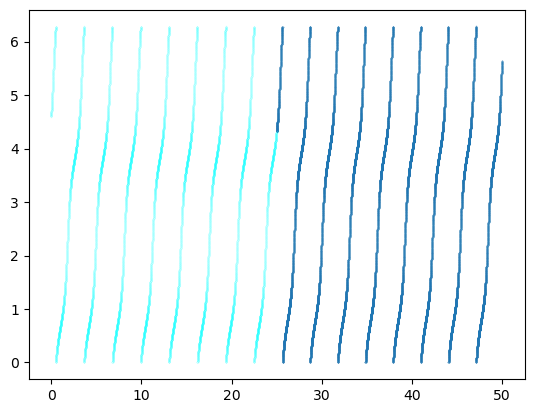

In [791]:

plt.plot((np.arange(trainlen,testlen+trainlen)*(h)),YPsi_test % (2*np.pi),'.',alpha=0.5, markersize=0.5,label='testing');
plt.plot(np.arange(0,trainlen)*(h), YPsi_train % (2*np.pi),'.', alpha=0.5, markersize=0.1,label='training',color='cyan')

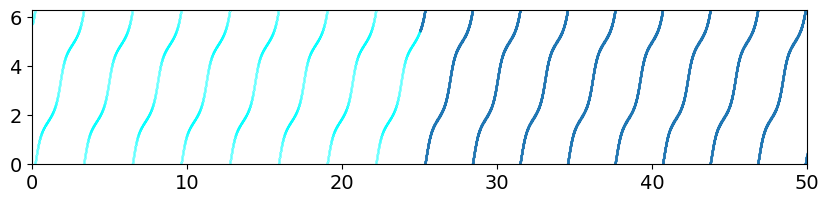

In [792]:

plt.figure(figsize=(10, 2))
plt.plot((np.arange(trainlen,testlen+trainlen)*(h)),Upred.T % (2*np.pi),'.',alpha=0.5, markersize=0.5,label='testing');
plt.plot(np.arange(0,trainlen)*(h), train_sol % (2*np.pi),'.', alpha=0.5, markersize=0.1,label='training',color='cyan')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim([0,50])
plt.ylim([0,2*np.pi])
plt.savefig(f'Pictures/period_traintest_lin{F}_{K}.jpg',dpi=300,bbox_inches = 'tight')
#plt.legend()
#plt.xlim([9_900,10_100])



In [793]:
Yrho_train = np.sqrt(np.real(Yz_train)**2 + np.imag(Yz_train)**2) 
Yrho_test = np.sqrt(np.real(Yz_test)**2 + np.imag(Yz_test)**2) 

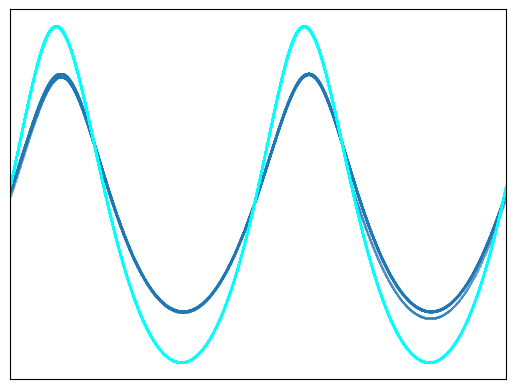

In [794]:

plt.plot( (YPsi_test % (2*np.pi)), (Yrho_test),'.', markersize=0.5)
plt.plot( (YPsi_train % (2*np.pi)), (Yrho_train),'.', markersize=0.5, color='cyan')
plt.xlim([0,2*np.pi])
plt.xticks([])
plt.yticks([])
plt.savefig(f'Pictures/period_psi_rho{F}_{K}.jpg',dpi=300,bbox_inches = 'tight')
#plt.plot( (YPsi_test % (2*np.pi))[0], (Yrho_test)[0],'.',)

In [233]:
def complex_norm(z):
    return np.sqrt(np.real(z)**2+np.imag(z)**2)

In [874]:
h=1e-3
v1 = 2

U_input = udata(h,v1=v1,M=1_000_000)

U0 = U_input[::2]
Umid =U_input[1::2]
U1 =U_input[2::2]

initlen=25_000
trainlen=25_000
testlen = 25_000

reg=1e-5

Fh =  151
Kh =  251

fixed_Z =[]

F_list = [] 
K_list = []
W_list = []
train_list = []
test_list = []
Ypoincare_list = []
for F in tqdm(np.linspace(0,1.85,Fh)):
    for K in np.linspace(1.75,7,Kh):
        p = np.array([K,F],dtype='float64')
        w= np.dtype('float64').type(1)
        z0=0.5+1j/2
        Yz, YPsi, angle_ind = solver(z0,U0,Umid,U1,p,h,w,steps =initlen+trainlen)
        Ypsi_sub = YPsi[initlen:]
        X_state=np.concatenate((np.expand_dims(np.ones(len(Ypsi_sub)),axis=0),\
                                      np.expand_dims(Ypsi_sub,axis=0)),axis=0)
        
        Yt = (U0[initlen:YPsi.shape[0]])  

        Wout = np.linalg.solve( np.matmul(X_state,X_state.T) + reg*np.eye(X_state.shape[0]) , np.matmul(X_state,Yt) ).T


        train_sol = np.matmul(Wout,X_state).T

        Yz_test, YPsi_test,Upred = solver_nou(Yz[-1],Yz[-2], Wout,p,h,w,angle_ind, steps =testlen) 
        Utrain = np.matmul(Wout,X_state).T
        # take the distance, normalize by max
        
        R =  np.sqrt((np.real(Yz_test[-500:])**2 + (np.real(Yz_test[-500:])**2)))
        R = R/max(R)
        fixed_Z.append(R.std())
        
        test_NMSE = NMSE(Upred[:5_000], U0[initlen+trainlen:initlen+trainlen+5_000 ])
        train_NMSE = NMSE(Utrain, U0[initlen:initlen+trainlen ])
        
        F_list.append(F)
        K_list.append(K)
        W_list.append(Wout)
        train_list.append(train_NMSE)
        test_list.append(test_NMSE)
        Yrho_test = np.sqrt(np.real(Yz_test)**2 + np.imag(Yz_test)**2) 
        Ypoincare = []

        psiold = YPsi_test[0]
        bi_int = int(psiold/(2*np.pi))
        for psi, rho in zip(YPsi_test[1:], Yrho_test):
            if psi-psiold > 0 and psi> (bi_int+1)*2*np.pi:
                bi_int +=1
                Ypoincare.append(rho)      
        
        Ypoincare_list.append(np.array(Ypoincare))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 151/151 [2:40:20<00:00, 63.71s/it]


In [682]:
W1list = [np.round(w[0] % (2*np.pi),3) for w in W_list]
W2list = [w[1] for w in W_list]

(149.0, 0.0)

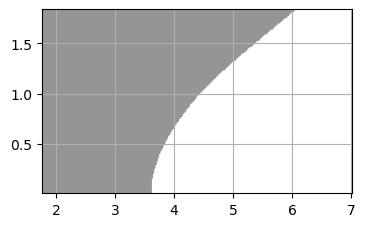

In [889]:
Amat = np.zeros((int((Kh-1)*(max(K_list)-1.75)/(7-1.75))+1,int((Fh-1)*(max(F_list)-0)/(1.85))+1))

for c0, K, F in zip(train_list,K_list,F_list):
    i = int(np.round((Kh-1)*(K-1.75)/(7-1.75)))
    j= int(np.round((Fh-1)*(F-0)/(1.85)))
    Amat[i,Amat.shape[1]-j-1] = c0
plt.figure(figsize=(4,3))
plt.imshow( ((Amat.T)<0.01), cmap ='Greys',vmin=0,vmax=2 )
plt.grid('on')
#plt.gca().set_aspect(2)
#plt.colorbar()
plt.xticks([-1+ (0.25/(7-1.75))*251 + (1/(7-1.75))*251*i for i in range(6) ], [2, 3, 4, 5,6,7])
plt.yticks([ -1+ 151 -  151*(0.25/1.85)*i*2 for i in range(4) ], [0,0.5,1.0,1.5])
plt.ylim([149,0])

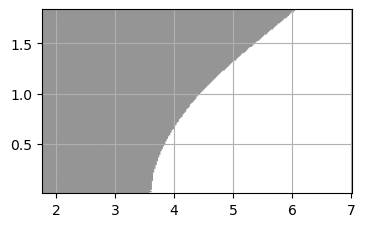

In [888]:
Amat = np.zeros((int((Kh-1)*(max(K_list)-1.75)/(7-1.75))+1,int((Fh-1)*(max(F_list)-0)/(1.85))+1))

for c0, K, F in zip(test_list,K_list,F_list):
    i = int(np.round((Kh-1)*(K-1.75)/(7-1.75)))
    j= int(np.round((Fh-1)*(F-0)/(1.85)))
    Amat[i,Amat.shape[1]-j-1] = c0
plt.figure(figsize=(4,3))
plt.imshow( ((Amat.T)<0.01), cmap ='Greys',vmin=0,vmax=2 )
plt.grid('on')

plt.xticks([-1+ (0.25/(7-1.75))*251 + (1/(7-1.75))*251*i for i in range(6) ], [2, 3, 4, 5,6,7])
plt.yticks([ -1+ 151 -  151*(0.25/1.85)*i*2 for i in range(4) ], [0,0.5,1.0,1.5])
plt.ylim([149,0])

plt.savefig(f'Pictures/test.jpg',dpi=200,bbox_inches = 'tight')

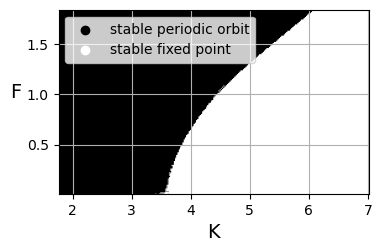

In [887]:
Amat = np.zeros((int((Kh-1)*(max(K_list)-1.75)/(7-1.75))+1,int((Fh-1)*(max(F_list)-0)/(1.85))+1))+1/2

for c0, K, F in zip(Ypoincare_list,K_list,F_list):
    i = int(np.round((Kh-1)*(K-1.75)/(7-1.75)))
    j= int(np.round((Fh-1)*(F-0)/(1.85)))
    if len(c0)>=3:
        if c0[-4:].std()<0.01:
            Amat[i,Amat.shape[1]-j-1] = 1


# Bmat = np.zeros((int((Kh-1)*(max(K_list)-1.75)/(7-1.75))+1,int((Fh-1)*(max(F_list)-0)/(1.85))+1))

for c0, K, F in zip(fixed_Z,K_list,F_list):
    i = int(np.round((Kh-1)*(K-1.75)/(7-1.75)))
    j= int(np.round((Fh-1)*(F-0)/(1.85)))
    if c0<1e-4:
        Amat[i,Amat.shape[1]-j-1] = 0            
            
            
plt.figure(figsize=(4,3))
#plt.imshow( ((Amat.T)<0.01), cmap ='Greys',vmin=0,vmax=2 )
plt.imshow( ((Amat.T)), cmap ='Greys',vmin=0,vmax=1 )
plt.xlabel('K',fontsize=14)
plt.ylabel('F', rotation=0,fontsize=14,labelpad=8)
plt.scatter(50,20,color='black',label='stable periodic orbit')
plt.scatter(250,5,color='white',label='stable fixed point')
plt.legend(loc='upper left')
plt.grid('on')
#plt.gca().set_aspect(2)
#plt.colorbar()
plt.xticks([-1+ (0.25/(7-1.75))*251 + (1/(7-1.75))*251*i for i in range(6) ], [2, 3, 4, 5,6,7])
plt.yticks([ -1+ 151 -  151*(0.25/1.85)*i*2 for i in range(4) ], [0,0.5,1.0,1.5])
plt.ylim([149,0])
plt.savefig(f'Pictures/fixed_pt.jpg',dpi=200,bbox_inches = 'tight')

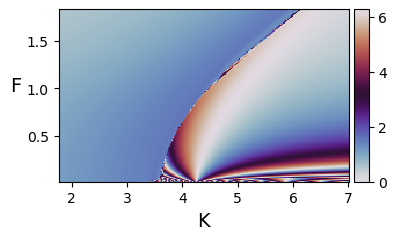

In [830]:

Amat = np.zeros((int((Kh-1)*(max(K_list)-1.75)/(7-1.75))+1,int((Fh-1)*(max(F_list)-0)/(1.85))+1))

for c0, K, F in zip(W1list,K_list,F_list):
    i = int(np.round((Kh-1)*(K-1.75)/(7-1.75)))
    j= int(np.round((Fh-1)*(F-0)/(1.85)))
    Amat[i,Amat.shape[1]-j-1] = c0
#plt.figure(figsize=(4,3))
plt.figure(figsize=(4,3))
ax = plt.gca()
plt.gca().set_aspect(200)
im = ax.imshow(Amat.T, cmap ='twilight',interpolation='nearest' )

#plt.colorbar()
plt.xticks([-1+ (0.25/(7-1.75))*251 + (1/(7-1.75))*251*i for i in range(6) ], [2, 3, 4, 5,6,7])
plt.yticks([ -1+ 151 -  151*(0.25/1.85)*i*2 for i in range(4) ], [0,0.5,1.0,1.5])
#plt.xlim([80,250])
plt.ylim([149,0])
plt.xlabel('K',fontsize=14)
plt.ylabel('F', rotation=0,fontsize=14,labelpad=8)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

plt.colorbar(im, cax=cax)

plt.savefig(f'Pictures/W1.jpg',dpi=200,bbox_inches = 'tight')

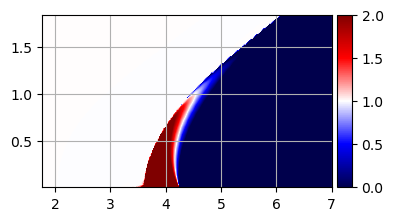

In [816]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

Amat = np.zeros((int((Kh-1)*(max(K_list)-1.75)/(7-1.75))+1,int((Fh-1)*(max(F_list)-0)/(1.85))+1))

for c0, K, F in zip(W2list,K_list,F_list):
    i = int(np.round((Kh-1)*(K-1.75)/(7-1.75)))
    j= int(np.round((Fh-1)*(F-0)/(1.85)))
    Amat[i,Amat.shape[1]-j-1] = c0
plt.figure(figsize=(4,3))
ax = plt.gca()
im=ax.imshow(Amat.T,vmin=0,vmax=2, cmap ='seismic' )
plt.grid('on')
plt.xticks([-1+ (0.25/(7-1.75))*251 + (1/(7-1.75))*251*i for i in range(6) ], [2, 3, 4, 5,6,7])
plt.yticks([ -1+ 151 -  151*(0.25/1.85)*i*2 for i in range(4) ], [0,0.5,1.0,1.5])
plt.ylim([149,0])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)
plt.savefig(f'Pictures/W2.jpg',dpi=200,bbox_inches = 'tight')